# Diabetes Classification Analysis

## Introduction and Objective

This project analyzes the Pima Indians Diabetes Dataset to build and evaluate binary classification models for predicting diabetes. The workflow includes data quality assessment, exploratory data analysis (EDA), model training, evaluation, and performance improvement through feature selection, class balancing, hyperparameter tuning, and an alternative Random Forest model.

The main objective is to identify a model that performs well overall while also effectively detecting diabetic cases. This is especially important in medical screening tasks, where missing true diabetic cases can have serious consequences.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

plt.figure(figsize=(1,1))
plt.close()

sns.set_style("whitegrid")

In [31]:
!git clone https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset.git

df = pd.read_csv("Pima-Indians-Diabetes-Dataset/diabetes.csv")
df.head()

fatal: destination path 'Pima-Indians-Diabetes-Dataset' already exists and is not an empty directory.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Quality Assessment

The dataset contains 768 observations and 8 predictor variables along with one binary outcome variable. There are no formally missing values, but several variables such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain zero values, which are not physiologically plausible and likely represent missing or unrecorded measurements.

These invalid zero values need to be handled before modeling because retaining them could bias the analysis and reduce predictive performance. Addressing them is an important part of improving data quality and building a more reliable classifier.

In [33]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_with_zero:
    df_clean = df_clean[df_clean[col] != 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Original shape: (768, 9)
Cleaned shape: (392, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


## Data Cleaning and Preprocessing

Rows containing zero values in key medical variables were removed so that only physiologically valid observations were used in the analysis. This improves data reliability by eliminating unrealistic measurements that are likely placeholders for missing data.

Although median imputation could also have been used, row removal was chosen here to avoid introducing additional assumptions into the dataset. This reduces the sample size substantially, so there is a trade-off between higher data quality and lower data quantity, but the cleaned dataset is more suitable for model training.

# **Exploratory Data Analysis**

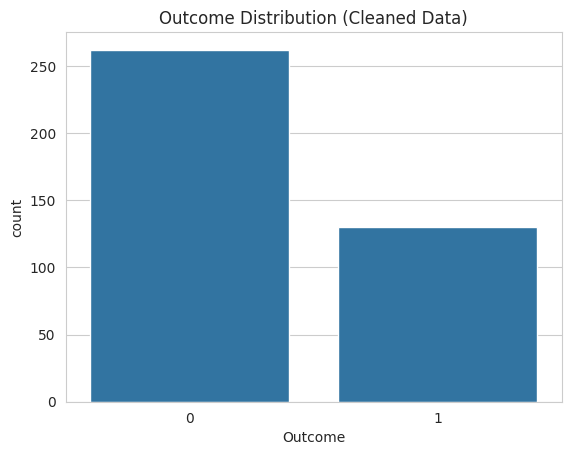

In [34]:
sns.countplot(x='Outcome', data=df_clean)
plt.title("Outcome Distribution (Cleaned Data)")
plt.show()

## Exploratory Data Analysis: Outcome Distribution

A count plot was selected because it clearly shows the number of diabetic and non-diabetic cases in the cleaned dataset. This is useful for detecting class imbalance, which can influence model behavior and evaluation.

The plot shows that the cleaned dataset remains moderately imbalanced, with more non-diabetic than diabetic cases. This imbalance matters because a model may become biased toward the majority class and perform worse at identifying true diabetic cases.

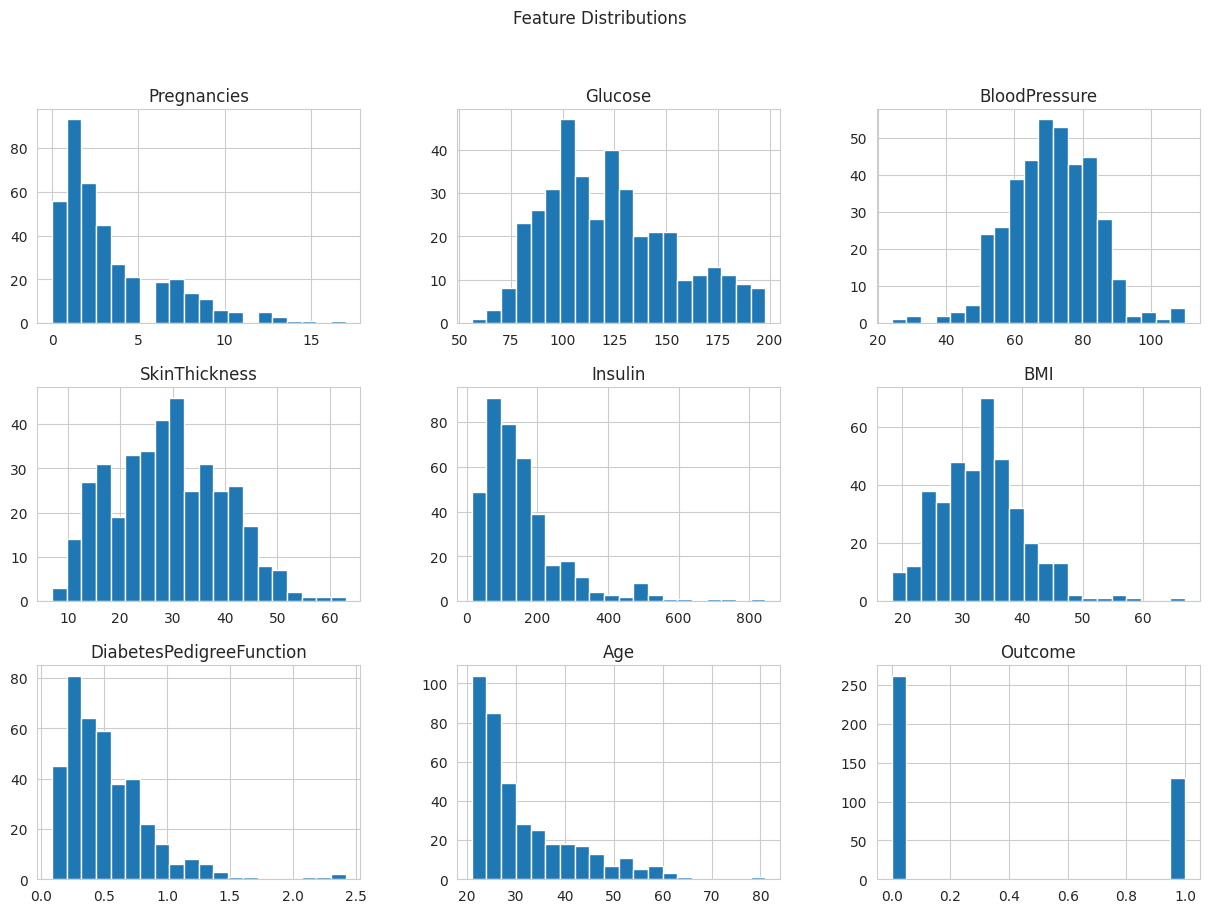

In [35]:
df_clean.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

## Exploratory Data Analysis: Feature Distributions

Histograms were used to examine the distribution of each feature because they show shape, spread, skewness, and possible outliers. Understanding feature distributions is important before modeling, especially for methods such as Logistic Regression that benefit from scaled inputs.

Most variables, including Glucose, BMI, and Age, appear somewhat right-skewed, meaning higher values are less frequent but still present. Insulin and SkinThickness show stronger skewness and variability, suggesting potential outliers and reinforcing the need for scaling before model fitting.

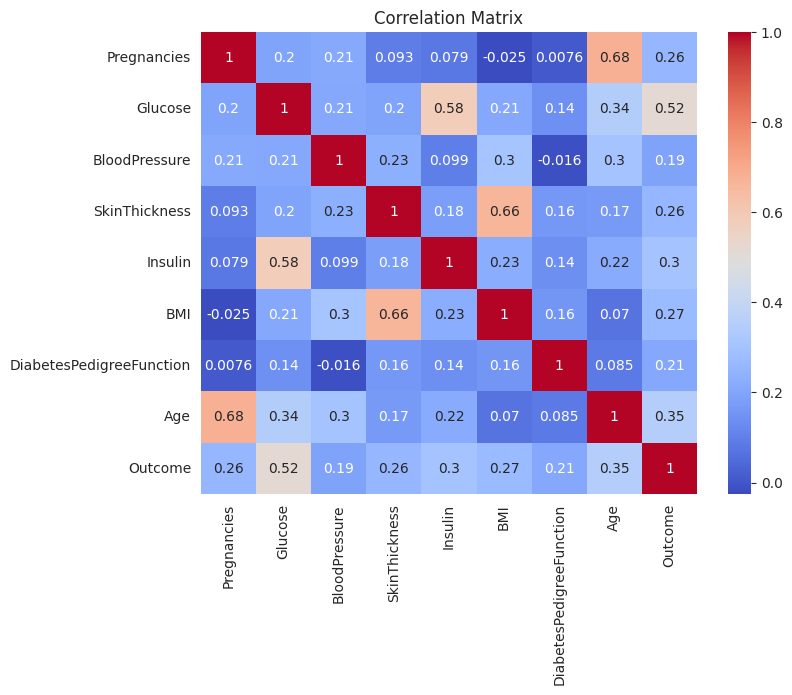

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis

A heatmap was selected because it provides a clear overview of the relationships between all variables at the same time. This helps identify which predictors are more strongly associated with the target variable and can guide feature selection.

The heatmap indicates that Glucose has the strongest correlation with diabetes outcome, followed by Age, BMI, and Pregnancies. These variables appear to be the most informative predictors and therefore provide a reasonable basis for feature selection in later modeling steps.

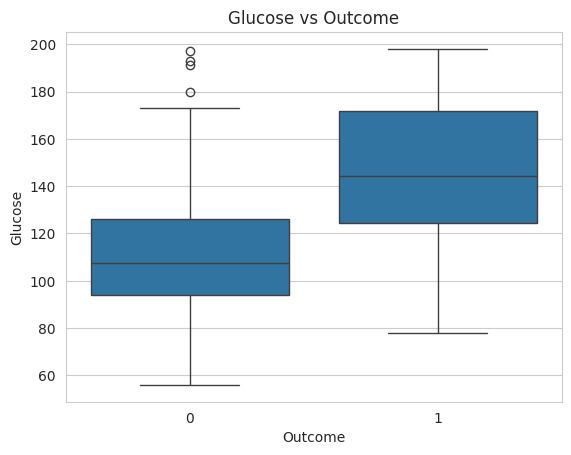

In [37]:
sns.boxplot(x='Outcome', y='Glucose', data=df_clean)
plt.title("Glucose vs Outcome")
plt.show()

## Glucose vs Outcome

A boxplot was chosen because it allows comparison of the distribution of glucose levels across diabetic and non-diabetic groups. It shows differences in median, spread, and outliers more clearly than a simple average comparison.

The plot suggests that individuals with diabetes tend to have noticeably higher glucose values than those without diabetes. This supports the earlier correlation analysis and confirms glucose as one of the most important predictors in the dataset.

Define Features and Target

In [38]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# **Train-Test Split**

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (313, 8)
X_test shape: (79, 8)
y_train shape: (313,)
y_test shape: (79,)


## Train-Test Split

The dataset was divided into training and test sets so that the model could be trained on one portion of the data and evaluated on unseen examples. A stratified split was used to preserve the class distribution in both sets, which is especially important because the target variable is moderately imbalanced.

# **Feature Scaling**

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature Scaling

Feature scaling was applied because Logistic Regression performs better when predictors are on comparable scales. Standardization ensures that variables with larger numeric ranges do not dominate the optimization process and helps improve model convergence.

## Baseline Model: Logistic Regression Using All Features

To establish a fair baseline, Logistic Regression was first trained using all available features after preprocessing and scaling. This allows evaluation of model performance before applying feature selection, class balancing, or hyperparameter tuning.

In [41]:
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(X_train_scaled, y_train)

y_pred_full = lr_full.predict(X_test_scaled)
y_prob_full = lr_full.predict_proba(X_test_scaled)[:, 1]

acc_full = accuracy_score(y_test, y_pred_full)
prec_full = precision_score(y_test, y_pred_full)
rec_full = recall_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)
roc_full = roc_auc_score(y_test, y_prob_full)

print("Baseline Logistic Regression (All Features)")
print("Accuracy:", acc_full)
print("Precision:", prec_full)
print("Recall:", rec_full)
print("F1:", f1_full)
print("ROC-AUC:", roc_full)

Baseline Logistic Regression (All Features)
Accuracy: 0.8354430379746836
Precision: 0.782608695652174
Recall: 0.6923076923076923
F1: 0.7346938775510204
ROC-AUC: 0.8875181422351234


## Baseline Model Performance

The baseline Logistic Regression model achieved an accuracy of 0.835, precision of 0.783, recall of 0.692, F1 score of 0.735, and ROC-AUC of 0.888. These results indicate strong overall performance and good class separation.

However, recall is relatively low compared to other metrics, meaning that several diabetic cases are missed. In a medical context, this is a critical limitation because false negatives represent undiagnosed diabetic individuals. Therefore, improving recall is necessary for a more reliable screening model.

# Baseline Confusion Matrix

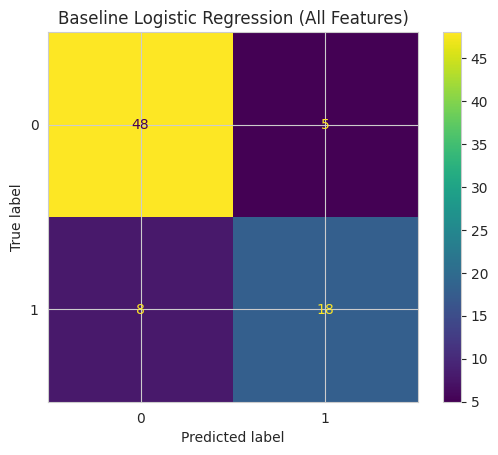

In [42]:
ConfusionMatrixDisplay.from_estimator(lr_full, X_test_scaled, y_test)
plt.title("Baseline Logistic Regression (All Features)")
plt.show()

## Interpretation of Baseline Confusion Matrix

The confusion matrix shows that the model correctly classified 48 non-diabetic cases and 18 diabetic cases. However, it misclassified 8 diabetic individuals as non-diabetic (false negatives) and 5 non-diabetic individuals as diabetic (false positives).

The relatively high number of false negatives explains the lower recall (0.69). This indicates that while the model performs well overall, it fails to identify several true diabetic cases, which is a major limitation for medical screening purposes.

### Proposed Improvements to Baseline Model

The baseline model can be improved by selecting the most relevant features, addressing class imbalance using class weighting, and tuning hyperparameters to optimize model performance. These steps aim to improve recall and overall predictive ability, particularly for identifying diabetic cases.

# Feature Selection

In [43]:
important_features = ['Glucose', 'BMI', 'Age', 'Pregnancies']

X_train_fs = X_train[important_features]
X_test_fs = X_test[important_features]

scaler_fs = StandardScaler()
X_train_fs = scaler_fs.fit_transform(X_train_fs)
X_test_fs = scaler_fs.transform(X_test_fs)

## Feature Selection

Feature selection was performed using the variables that showed stronger relationships with the target in the exploratory analysis, namely Glucose, BMI, Age, and Pregnancies. This was done to simplify the model, reduce noise from less informative variables, and improve interpretability.

Using fewer but more relevant predictors can sometimes improve generalization and make the model focus on the features that matter most for classification.

# Logistic Regression with Feature Selection

In [44]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_fs, y_train)

y_pred_lr = lr.predict(X_test_fs)
y_prob_lr = lr.predict_proba(X_test_fs)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression (Feature Selection)")
print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1:", f1_lr)
print("ROC-AUC:", roc_lr)

Logistic Regression (Feature Selection)
Accuracy: 0.8354430379746836
Precision: 0.76
Recall: 0.7307692307692307
F1: 0.7450980392156863
ROC-AUC: 0.8759071117561684


## Performance After Feature Selection

After feature selection, the model achieved an accuracy of 0.835, precision of 0.76, recall of 0.731, F1 score of 0.745, and ROC-AUC of 0.876.

Recall improved from 0.69 to 0.73 compared to the baseline model, indicating better identification of diabetic cases. At the same time, the model remains simple and interpretable. This suggests that removing less informative features helped improve model focus without sacrificing overall performance.

# Feature Selection Confusion Matrix

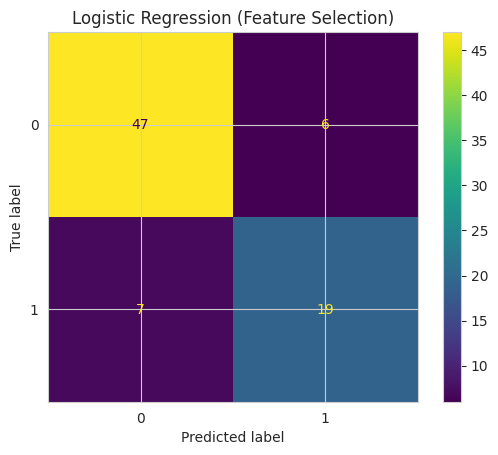

In [45]:
ConfusionMatrixDisplay.from_estimator(lr, X_test_fs, y_test)
plt.title("Logistic Regression (Feature Selection)")
plt.show()

## Interpretation of Feature Selection Confusion Matrix

The confusion matrix shows that the model correctly classified 47 non-diabetic cases and 19 diabetic cases. It misclassified 7 diabetic cases as non-diabetic and 6 non-diabetic cases as diabetic.

Compared to the baseline model, false negatives decreased from 8 to 7, leading to improved recall. This indicates that feature selection slightly improved the model’s ability to detect diabetic individuals while maintaining strong performance on non-diabetic cases.

## Balanced Logistic Regression

Because the cleaned dataset is still moderately imbalanced, class weighting was applied to Logistic Regression. This gives more importance to correctly identifying diabetic cases and aims to improve recall.

In [46]:
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_bal.fit(X_train_fs, y_train)

y_pred_bal = lr_bal.predict(X_test_fs)
y_prob_bal = lr_bal.predict_proba(X_test_fs)[:, 1]

acc_bal = accuracy_score(y_test, y_pred_bal)
prec_bal = precision_score(y_test, y_pred_bal)
rec_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_bal = roc_auc_score(y_test, y_prob_bal)

print("Balanced Logistic Regression")
print("Accuracy:", acc_bal)
print("Precision:", prec_bal)
print("Recall:", rec_bal)
print("F1:", f1_bal)
print("ROC-AUC:", roc_bal)

Balanced Logistic Regression
Accuracy: 0.810126582278481
Precision: 0.6774193548387096
Recall: 0.8076923076923077
F1: 0.7368421052631579
ROC-AUC: 0.876632801161103


## Performance of Balanced Logistic Regression

The balanced Logistic Regression model achieved an accuracy of 0.810, precision of 0.677, recall of 0.808, F1 score of 0.737, and ROC-AUC of 0.877.

Recall improved significantly compared to previous models, increasing from 0.73 to 0.81. This means the model is much better at identifying diabetic cases. Although precision decreased, resulting in more false positives, this trade-off is acceptable in medical screening, where minimizing missed cases is more important than avoiding false alarms.

# Balanced Confusion Matrix

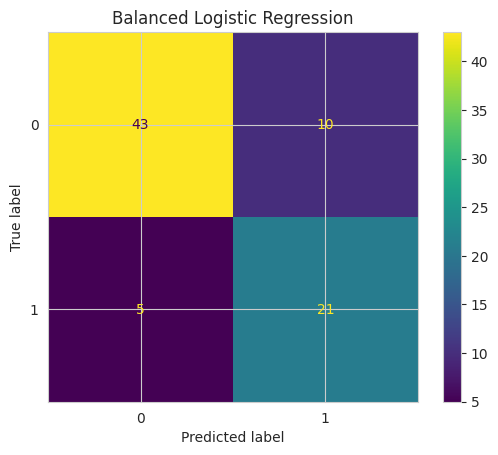

In [47]:
ConfusionMatrixDisplay.from_estimator(lr_bal, X_test_fs, y_test)
plt.title("Balanced Logistic Regression")
plt.show()

## Interpretation of Balanced Logistic Regression Confusion Matrix

The confusion matrix shows that the model correctly classified 43 non-diabetic cases and 21 diabetic cases. Only 5 diabetic cases were missed (false negatives), which is lower than previous models.

However, false positives increased to 10, indicating more non-diabetic individuals were incorrectly classified as diabetic. This explains the drop in precision but confirms the strong improvement in recall. Overall, this model is more suitable for medical screening because it minimizes missed diabetic cases.

## Hyperparameter Tuning

Hyperparameter tuning was applied to the balanced Logistic Regression model to test whether adjusting regularization strength could further improve performance. GridSearchCV was used to identify the best parameter setting using cross-validation on the training data.

In [48]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    cv=3
)
grid_lr.fit(X_train_fs, y_train)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_fs)
y_prob_lr_tuned = best_lr.predict_proba(X_test_fs)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_lr_tuned)
prec_tuned = precision_score(y_test, y_pred_lr_tuned)
rec_tuned = recall_score(y_test, y_pred_lr_tuned)
f1_tuned = f1_score(y_test, y_pred_lr_tuned)
roc_tuned = roc_auc_score(y_test, y_prob_lr_tuned)

print("Best Parameters:", grid_lr.best_params_)
print("Tuned Logistic Regression")
print("Accuracy:", acc_tuned)
print("Precision:", prec_tuned)
print("Recall:", rec_tuned)
print("F1:", f1_tuned)
print("ROC-AUC:", roc_tuned)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuned Logistic Regression
Accuracy: 0.7974683544303798
Precision: 0.65625
Recall: 0.8076923076923077
F1: 0.7241379310344828
ROC-AUC: 0.8780841799709724


## Performance of Tuned Logistic Regression

The tuned Logistic Regression model achieved an accuracy of 0.797, precision of 0.656, recall of 0.808, F1 score of 0.724, and ROC-AUC of 0.878.

While recall remained high and similar to the balanced model, precision and F1 score decreased slightly. This indicates that hyperparameter tuning did not improve overall model performance and introduced more false positives without improving detection of diabetic cases.

# Tuned Confusion Matrix

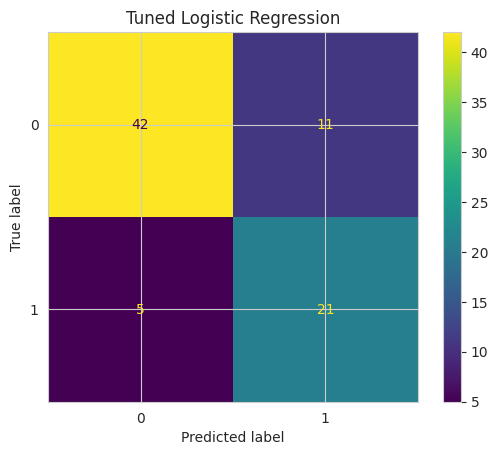

In [49]:
ConfusionMatrixDisplay.from_estimator(best_lr, X_test_fs, y_test)
plt.title("Tuned Logistic Regression")
plt.show()

## Interpretation of Tuned Logistic Regression Confusion Matrix

The confusion matrix shows that the model correctly classified 42 non-diabetic cases and 21 diabetic cases. It missed 5 diabetic cases, which is the same as the balanced model.

However, false positives increased further to 11, meaning more non-diabetic individuals were incorrectly classified as diabetic. This confirms that hyperparameter tuning did not provide a practical improvement and slightly worsened model precision.

## Alternative Model: Random Forest Classifier

As an alternative to Logistic Regression, a Random Forest classifier was also tested. Random Forest is useful because it can model non-linear relationships and interactions between predictors, which Logistic Regression may not capture fully.

This provides an opportunity to compare a tree-based ensemble model with the previous linear models and determine whether a more flexible method improves classification performance.

In [50]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)
print("ROC-AUC:", roc_rf)

Random Forest
Accuracy: 0.810126582278481
Precision: 0.72
Recall: 0.6923076923076923
F1: 0.7058823529411765
ROC-AUC: 0.861756168359942


## Performance of Random Forest

The Random Forest model achieved an accuracy of 0.810, precision of 0.72, recall of 0.692, F1 score of 0.706, and ROC-AUC of 0.862.

Compared to Logistic Regression models, Random Forest shows lower recall and ROC-AUC, indicating that it is less effective at identifying diabetic cases. This suggests that the dataset relationships are sufficiently captured by linear models, and the additional complexity of Random Forest does not provide a performance advantage.

# Random Forest Confusion Matrix

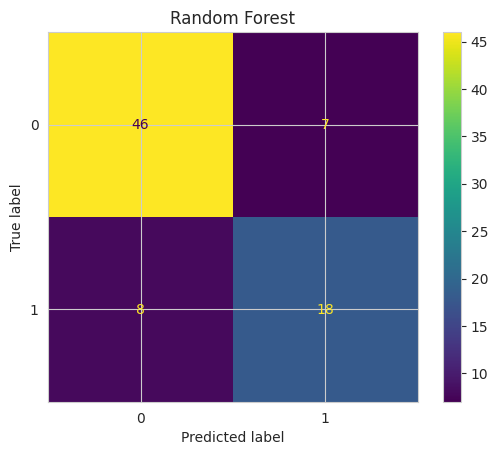

In [51]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest")
plt.show()

## Interpretation of Random Forest Confusion Matrix

The confusion matrix shows that the model correctly classified 46 non-diabetic cases and 18 diabetic cases. However, it misclassified 8 diabetic cases as non-diabetic and 7 non-diabetic cases as diabetic.

The number of false negatives is similar to the baseline model and higher than the balanced Logistic Regression model. This indicates that Random Forest is less effective at detecting diabetic cases, making it less suitable for medical screening where recall is critical.

<Figure size 800x600 with 0 Axes>

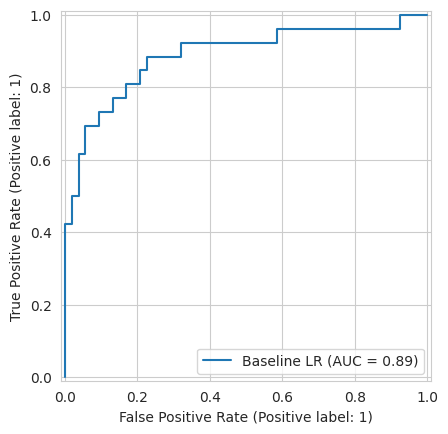

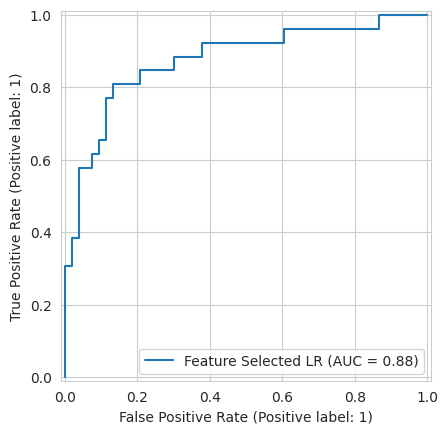

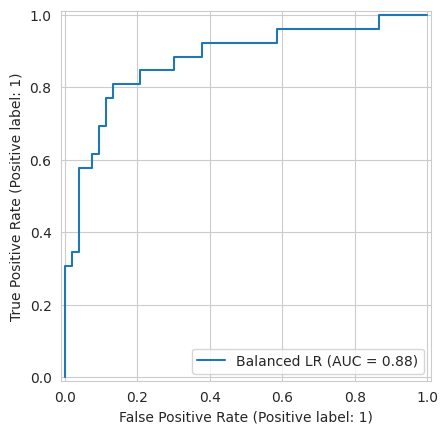

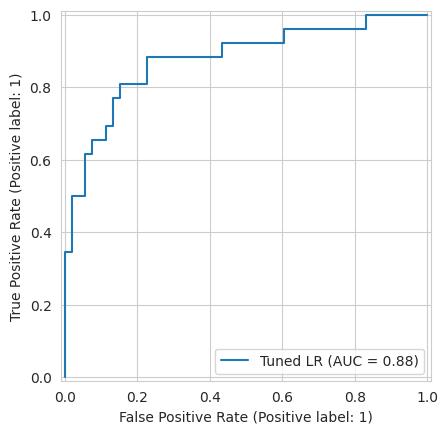

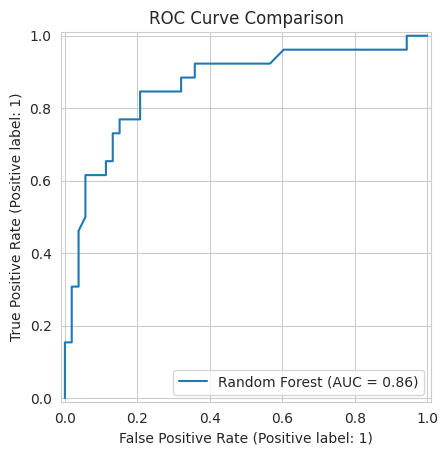

In [52]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_full, name='Baseline LR')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Feature Selected LR')
RocCurveDisplay.from_predictions(y_test, y_prob_bal, name='Balanced LR')
RocCurveDisplay.from_predictions(y_test, y_prob_lr_tuned, name='Tuned LR')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest')

plt.title("ROC Curve Comparison")
plt.show()

## ROC Curve Comparison

The ROC curves show that all Logistic Regression models perform similarly, with ROC-AUC values around 0.87–0.89, indicating strong classification ability. The baseline model has the highest ROC-AUC (~0.89), while the balanced and tuned models maintain similar performance.

The Random Forest model has a slightly lower ROC-AUC (~0.86), confirming that it is less effective at distinguishing between diabetic and non-diabetic cases compared to Logistic Regression models.

In [53]:
results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Feature Selection Logistic Regression",
        "Balanced Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [acc_full, acc_lr, acc_bal, acc_tuned, acc_rf],
    "Precision": [prec_full, prec_lr, prec_bal, prec_tuned, prec_rf],
    "Recall": [rec_full, rec_lr, rec_bal, rec_tuned, rec_rf],
    "F1 Score": [f1_full, f1_lr, f1_bal, f1_tuned, f1_rf],
    "ROC-AUC": [roc_full, roc_lr, roc_bal, roc_tuned, roc_rf]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.835443,0.782609,0.692308,0.734694,0.887518
1,Feature Selection Logistic Regression,0.835443,0.760000,0.730769,0.745098,0.875907
2,Balanced Logistic Regression,0.810127,0.677419,0.807692,0.736842,0.876633
3,Tuned Logistic Regression,0.797468,0.656250,0.807692,0.724138,0.878084
4,Random Forest,0.810127,0.720000,0.692308,0.705882,0.861756


In [54]:
results.sort_values(by=["Recall", "F1 Score", "ROC-AUC"], ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Balanced Logistic Regression,0.810127,0.677419,0.807692,0.736842,0.876633
3,Tuned Logistic Regression,0.797468,0.656250,0.807692,0.724138,0.878084
1,Feature Selection Logistic Regression,0.835443,0.760000,0.730769,0.745098,0.875907
0,Baseline Logistic Regression,0.835443,0.782609,0.692308,0.734694,0.887518
4,Random Forest,0.810127,0.720000,0.692308,0.705882,0.861756


## Model Comparison


The comparison of all models shows that the baseline Logistic Regression achieved strong overall performance but had relatively low recall. Feature selection improved recall slightly while simplifying the model.

Balanced Logistic Regression achieved the highest recall (0.81), making it the most effective model for detecting diabetic cases. The tuned Logistic Regression model did not improve performance further and slightly reduced precision. The Random Forest model performed reasonably well but had lower recall and ROC-AUC compared to Logistic Regression models.

Overall, Balanced Logistic Regression provides the best balance between detecting diabetic cases and maintaining acceptable overall performance.

# Conclusion

This study demonstrates that careful data preprocessing, exploratory analysis, and model optimization are essential for building effective classification models. Removing physiologically invalid zero values improved data quality, although it reduced dataset size.

Exploratory analysis identified Glucose, BMI, Age, and Pregnancies as key predictors. Among all models, Balanced Logistic Regression performed best by achieving the highest recall (0.81), significantly reducing false negatives.

Although Random Forest provided comparable accuracy, it failed to improve recall, making it less suitable for medical screening. Hyperparameter tuning did not lead to further improvement, indicating that the balanced model was already optimal.

Therefore, Balanced Logistic Regression is the most suitable model for this task, particularly because minimizing false negatives is critical in medical applications.

## Project Repository

The complete notebook and supporting files for this assignment are available at:

https://github.com/jasneetsingh1141/diabetes-classification-project.git